# Two Pointers — LeetCode Questions (8 Qs)

Pattern: use left & right pointers moving toward each other (or same direction)
Key insight: avoid O(n^2) nested loops by moving smartly with 2 pointers

1. 167 – Two Sum II (Sorted Array)
2. 977 – Squares of a Sorted Array
3. 11  – Container With Most Water
4. 42  – Trapping Rain Water  [Hard — FAANG Favorite]
5. 15  – 3Sum  [FAANG Classic]
6. 16  – 3Sum Closest
7. 75  – Sort Colors (Dutch National Flag)
8. 680 – Valid Palindrome II

# 1. LeetCode 167 – Two Sum II (Input Array Is Sorted)

Given a 1-indexed sorted array, return indices of two numbers that add to target.
Array is sorted ascending. Use O(1) extra space.

Input: numbers = [2, 7, 11, 15], target = 9

## Dry Run

| Step | left | right | numbers[left] | numbers[right] | Sum | Action |
|------|------|-------|---------------|----------------|-----|--------|
| 1 | 0 | 3 | 2 | 15 | 17 | 17 > 9 → right-- |
| 2 | 0 | 2 | 2 | 11 | 13 | 13 > 9 → right-- |
| 3 | 0 | 1 | 2 | 7 | 9 | 9 == 9 → Return [1, 2] |

In [5]:

from typing import List

class Solution:
    def twoSum(self, numbers: List[int], target: int) -> List[int]:
        left, right = 0, len(numbers) - 1 #0,3
        while left < right: #0<3
            s = numbers[left] + numbers[right] # 2 + 15=17
            if s  == target: #17 ==9
                return [left+1 , right+1] # 1-indexed
            elif s < target: #17 < 9
                left += 1
            else: # s> target
                right -= 1

print(Solution().twoSum([2, 7, 11, 15], 9))   # [1, 2]
print(Solution().twoSum([2, 3, 4], 6))         # [1, 3]

[1, 2]
[1, 3]


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – each pointer moves at most n times | O(1) – only two pointer variables |
| **Final: O(n)** | **Final: O(1)** |

> Brute Force O(n^2): two nested loops
> Optimized O(n): two pointers on sorted array

# 2. LeetCode 977 – Squares of a Sorted Array

Given array sorted in non-decreasing order (may have negatives),
return array of squares sorted ascending.

Input: [-4, -1, 0, 3, 10]  Output: [0, 1, 9, 16, 100]

## Dry Run

Two pointers: left=0, right=4. Fill result from the END (largest square first).

| Step | left | right | nums[l]^2 | nums[r]^2 | Winner | result |
|------|------|-------|-----------|-----------|--------|--------|
| 1 | 0 | 4 | 16 | 100 | 100 (right) | [_,_,_,_,100] |
| 2 | 0 | 3 | 16 | 9 | 16 (left) | [_,_,_,16,100] |
| 3 | 1 | 3 | 1 | 9 | 9 (right) | [_,_,9,16,100] |
| 4 | 1 | 2 | 1 | 0 | 1 (left) | [_,1,9,16,100] |
| 5 | 2 | 2 | 0 | 0 | 0 (equal) | [0,1,9,16,100] |

In [8]:
class Solution:
    def sortedSquares(self, nums: List[int]) -> List[int]:
        n = len(nums)#5
        result = [0] * n #[0,0,0,0,0]
        left, right = 0, n - 1 # 4
        pos = n - 1     #5-1=4      # fill from rightmost position
        while left <= right :#0<4
            lsq = nums[left] ** 2
            rsq = nums[right] ** 2
            if lsq > rsq:
                result[pos] = lsq
                left += 1
            else:
                result[pos] = rsq
                right -= 1
            pos -= 1  
        return result      
print(Solution().sortedSquares([-4, -1, 0, 3, 10]))  # [0,1,9,16,100]

[0, 1, 9, 16, 100]


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – single pass with two pointers | O(n) – output result array |
| **Final: O(n)** | **Final: O(n)** |

# 3. LeetCode 11 – Container With Most Water

Given height array, find two lines forming largest container of water.
Width = distance between lines, Height = min of the two lines.

Input: height = [1,8,6,2,5,4,8,3,7]  Output: 49

From Example 1: height = [1,8,6,2,5,4,8,3,7]   
The maximum area is 49 between lines at index 1 (height 8) and index 8 (height 7):  
Width = 8 - 1 = 7  
Height = min(8, 7) = 7  
Area = 7 * 7 = 49


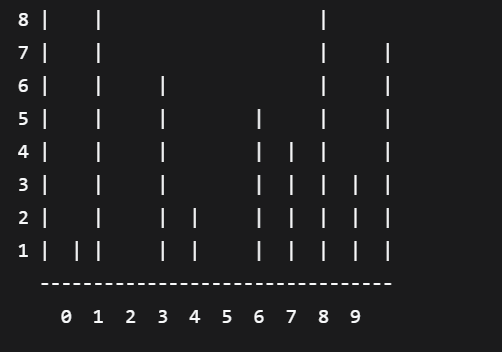

## Dry Run
height = [1,8,6,2,5,4,8,3,7]
index   0 1 2 3 4 5 6 7 8

Rules your code uses:  
#### width = right − left
#### height = min(height[left], height[right])
#### area = height × width
Move the pointer with the smaller height

Why smaller? Because the smaller wall limits the water. Moving the taller one changes nothing useful.
Move the pointer with the SMALLER height (can only help by finding bigger height).    


| Step | left | right | height[left] | height[right] | min height | width (r-l) | area | max_area | move      |
| ---- | ---- | ----- | ------------ | ------------- | ---------- | ----------- | ---- | -------- | --------- |
| 1    | 0    | 8     | 1            | 7             | 1          | 8           | 8    | 8        | left++    |
| 2    | 1    | 8     | 8            | 7             | 7          | 7           | 49   | **49**   | right--   |
| 3    | 1    | 7     | 8            | 3             | 3          | 6           | 18   | 49       | right--   |
| 4    | 1    | 6     | 8            | 8             | 8          | 5           | 40   | 49       | right--   |
| 5    | 1    | 5     | 8            | 4             | 4          | 4           | 16   | 49       | right--   |
| 6    | 1    | 4     | 8            | 5             | 5          | 3           | 15   | 49       | right--   |
| 7    | 1    | 3     | 8            | 2             | 2          | 2           | 4    | 49       | right--   |
| 8    | 1    | 2     | 8            | 6             | 6          | 1           | 6    | 49       | right--   |
| Stop | 1    | 1     | -            | -             | -          | -           | -    | **49**   | loop ends |


In [9]:
class Solution:
    def maxArea(self, height: List[int]) -> int:
        left, right = 0, len(height) - 1 #9-1=8
        max_water = 0
        while left < right: #0<8
            h = min(height[left], height[right])#(1,7)=1
            width = right - left #8-0 =8
            max_water = max(max_water, h * width) # max(0,1*8 )=max(0,8)=8
            if height[left]< height[right]:# 1<7
                left += 1
            else:
                right -= 1
        return max_water            
print(Solution().maxArea([1,8,6,2,5,4,8,3,7]))  # 49
     

49


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – each pointer moves at most n steps | O(1) – only variables |
| **Final: O(n)** | **Final: O(1)** |

# 4. LeetCode 42 – Trapping Rain Water [Hard — FAANG Favorite]



## Problem
Given an array `height` representing the height of bars, compute how much rainwater can be trapped between them after raining.

Example:

```
height = [0,1,0,2,1,0,1,3,2,1,2,1]
```

Visual idea:

```
        █
    █   █
█   █ █ █
█ █ █ █ █
```

Water gets trapped between taller bars.

---

# Key Insight

Water trapped at index `i` is:

```
min(max_left, max_right) - height[i]
```

Where:

- `max_left` = tallest bar on the left
- `max_right` = tallest bar on the right

Water level is limited by the **shorter wall**.

---

# Optimal Approach (Two Pointer)

Instead of checking left and right for every element, we use:

- `left` pointer
- `right` pointer
- track `left_max`
- track `right_max`

Move the smaller side inward.

Time complexity becomes **O(n)**.

---


Meaning:

left → start pointer

right → end pointer

max_left → tallest wall seen from the left

max_right → tallest wall seen from the right

water → total trapped water

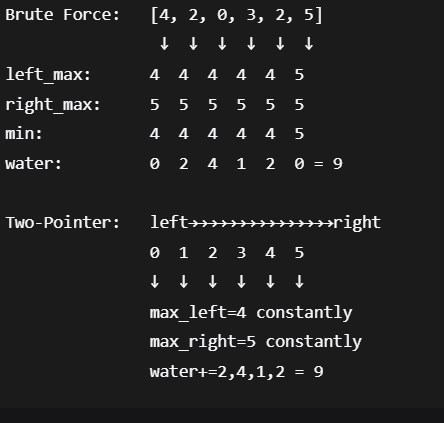

height = [0,1,0,2,1,0,1,3,2,1,2,1]   
index= 0 1 2 3 4 5 6 7 8 9 10 11   
Algorithm rule from your code:    


left = 0   
right = 11   
max_left = 0  
max_right = 1  
water = 0

## Dry Run (Two-Pointer Approach)

| left | right | height[left] | height[right] | max_left | max_right | water added | total water |
| ---- | ----- | ------------ | ------------- | -------- | --------- | ----------- | ----------- |
| 0    | 11    | 0            | 1             | 0        | 1         | 0           | 0           |
| 1    | 11    | 1            | 1             | 1        | 1         | 0           | 0           |
| 2    | 11    | 0            | 1             | 1        | 1         | 1           | 1           |
| 3    | 11    | 2            | 1             | 1        | 1         | 0           | 1           |
| 3    | 10    | 2            | 2             | 1        | 2         | 0           | 1           |
| 4    | 10    | 1            | 2             | 2        | 2         | 1           | 2           |
| 5    | 10    | 0            | 2             | 2        | 2         | 2           | 4           |
| 6    | 10    | 1            | 2             | 2        | 2         | 1           | 5           |
| 7    | 10    | 3            | 2             | 2        | 2         | 0           | 5           |
| 7    | 9     | 3            | 1             | 2        | 2         | 1           | 6           |


In [11]:
class Solution(object):
    def trap(self, height):
        if not height:
            return 0         
        left, right = 0, len(height) - 1 #11
        max_left = height[left]
        max_right = height[right]
        water = 0
        while left < right:#0<1
            if height[left] <= height[right]:
                if height[left]>= max_left:
                    max_left = height[left]
                else: 
                    water += max_left - height[left] 
                left += 1  
            else: #height[right] < height[left]:  
                if height[right]>= max_right:
                    max_right =  height[right]
                else:
                    water += max_right - height[right]    
                right -= 1    
        return water       
print(Solution().trap([0,1,0,2,1,0,1,3,2,1,2,1]))  # 6
print(Solution().trap([4,2,0,3,2,5]))               # 9

6
9


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – single pass | O(1) – only 4 variables |
| **Final: O(n)** | **Final: O(1)** |

> Naive approach: precompute maxLeft[] and maxRight[] arrays → O(n) time, O(n) space
> Optimal two-pointer: O(n) time, O(1) space

# 5. LeetCode 15 – 3Sum [FAANG Classic]

Find all UNIQUE triplets [i, j, k] where i != j != k and sum = 0.

Input: [-1, 0, 1, 2, -1, -4]  Output: [[-1,-1,2], [-1,0,1]]

## Dry Run

Sorted: [-4, -1, -1, 0, 1, 2]

For each fixed i, use two pointers on rest of array.

| i | nums[i] | left | right | sum | action |
|---|---------|------|-------|-----|--------|
| 0 | -4 | 1 | 5 | -4+-1+2=-3 | <0 → left++ |
| 0 | -4 | 4 | 5 | -4+1+2=-1 | <0 → left++ |
| 1 | -1 | 2 | 5 | -1+-1+2=0 | ==0 → add [-1,-1,2], move both |
| 1 | -1 | 3 | 4 | -1+0+1=0 | ==0 → add [-1,0,1], move both |
| 2 | -1 | skip (dup of i=1) | | | |
| 3 | 0 | 4 | 5 | 0+1+2=3 | >0 → right-- |
| Result | | | | | [[-1,-1,2], [-1,0,1]] |

left = 1  
right = 5 

| left | right | sum        | action |
| ---- | ----- | ---------- | ------ |
| 1    | 5     | -3         | left++ |
| 2    | 5     | -3         | left++ |
| 3    | 5     | -2         | left++ |
| 4    | 5     | -1         | left++ |
| 5    | 5     | loop stops |        |


Notice what happened.

left = 5
right = 5

Now check the loop condition:

left < right
5 < 5  → False

In [ ]:
class Solution:
    def threeSum(self, nums: List[int]) -> List[List[int]]:
        nums.sort()
        result = []
        for i in range(len(nums)-2):
            #6-2=4=>i=0,1,2,3
            if i>0 and nums[i] == nums[i-1]:
                 # 0>0 and nums[0 ]== nums[0-1],
                 # 1>0 and nums[1]== nums[1-1]
                 continue
            left , right = i+1 , len(nums)-1
            # (1, 5)=>i =0
            # (2,5)=> i =1
            while left < right: #1<5,5<5, 2<5, 3<4
                total =nums[i] + nums[left]+nums[right]
                # -4+(-1) +(2) = -3
                #-4+(-1)+2 =-3
                # -4 +0+2=-2
                # -4 +1+2=-1 
                # -1+(-1)+2 =0
                #-1+0+1 =0
                if total == 0:
                    result.append([nums[i], nums[left],nums[right]])
                    while left < right and nums[left] == nums[left+1]:
                        left += 1
                    while left< right and nums[right]== nums[right-1]:
                        right -= 1
                    left += 1
                    right -=1
                elif total < 0:#-3<0,-1<0
                    left += 1
                else:
                    right -= 1
        return result             
print(Solution().threeSum([-1, 0, 1, 2, -1, -4]))  # [[-1,-1,2],[-1,0,1]]
print(Solution().threeSum([0, 0, 0]))               # [[0,0,0]]

[[-1, -1, 2], [-1, 0, 1]]
[[0, 0, 0]]


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n log n) sort + O(n^2) two pointer = O(n^2) | O(1) extra (output list not counted) |
| **Final: O(n^2)** | **Final: O(1) extra** |

> Brute Force O(n^3): three nested loops → TLE on large inputs
> Optimized O(n^2): Sort + two pointers

# 6. LeetCode 16 – 3Sum Closest

Find triplet whose sum is CLOSEST to target. Return the sum.

Input: nums=[-1,2,1,-4], target=1  Output: 2

## Dry Run

Sorted: [-4, -1, 1, 2], target = 1
| i | left | right | nums[i] | nums[left] | nums[right] | total | total < target? | action | abs(total-target) | abs(closest-target) | update closest? | closest |
|---|------|-------|--------|------------|-------------|-------|------------------|--------|-------------------|---------------------|-----------------|---------|
| 0 | 1 | 3 | -4 | -1 | 2 | -3 | -3 < 1 (True) | left++ | 4 | ∞ | YES (4 < ∞) | -3 |
| 0 | 2 | 3 | -4 | 1 | 2 | -1 | -1 < 1 (True) | left++ | 2 | 4 | YES (2 < 4) | -1 |
| 0 | 3 | 3 | -4 | 2 | 2 | - | - | loop ends (left=3, right=3, not <) | - | - | - | -1 |
| 1 | 2 | 3 | -1 | 1 | 2 | 2 | 2 < 1? (False) | right-- | 1 | 2 | YES (1 < 2) | 2 |
| 1 | 2 | 2 | -1 | 1 | 1 | - | - | loop ends (left=2, right=2, not <) | - | - | - | 2 |



In [17]:
class Solution:
    def threeSumClosest(self, nums: List[int], target: int) -> int:
        nums.sort()
        closest = float('inf')
        for i in range(len(nums)-2): # 4-2=2
            left , right = i+1, len(nums)-1 #(1,3), (2,3)
            while left < right: #1<3, 2<3, 3<3, 2<2
                total =nums[i] + nums[left]+nums[right]
                #-4+(-1)+2 =-3  
                #-4+1+2 = -1
                #-1+1+2=2
                if abs(total-target)<abs(closest- target):
                    # abs(-3-1)<abs(inf - 1)  
                    #abs(-1-1)<abs(-3-1)
                    #abs(2-1)<abs(-1-1)
                    closest = total #-3, -1, 2
                if total < target: # -3<1,-1<1, 2<1
                    left += 1
                elif total>target: # 2>1
                    right -= 1

                else:
                    return total 
        return closest           
print(Solution().threeSumClosest([-1, 2, 1, -4], 1))  # 2
print(Solution().threeSumClosest([0, 0, 0], 1))        # 0

2
0


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n log n) + O(n^2) two pointer = O(n^2) | O(1) extra space |
| **Final: O(n^2)** | **Final: O(1)** |

# 7. LeetCode 75 – Sort Colors (Dutch National Flag)

Sort array with only 0s, 1s, 2s IN-PLACE in a single pass.
3 pointers: low (next 0 slot), mid (current), high (next 2 slot)

Input: [2,0,2,1,1,0]  Output: [0,0,1,1,2,2]

0-red  
1-white  
2-blue     

## Dry Run

| Step | nums | low | mid | high | nums[mid] | action |
|------|------|-----|-----|------|-----------|--------|
| Start | [2,0,2,1,1,0] | 0 | 0 | 5 | 2 | swap(mid,high), high-- |
| 1 | [0,0,2,1,1,2] | 0 | 0 | 4 | 0 | swap(low,mid), low++, mid++ |
| 2 | [0,0,2,1,1,2] | 1 | 1 | 4 | 0 | swap(low,mid), low++, mid++ |
| 3 | [0,0,2,1,1,2] | 2 | 2 | 4 | 2 | swap(mid,high), high-- |
| 4 | [0,0,1,1,2,2] | 2 | 2 | 3 | 1 | mid++ |
| 5 | [0,0,1,1,2,2] | 2 | 3 | 3 | 1 | mid++ |
| done | [0,0,1,1,2,2] | | 4>3 | | loop ends | |

In [ ]:
from typing import List
class Solution:
    def sortColors(self, nums: List[int]) -> None:
        low, mid, high = 0, 0, len(nums) - 1 #6-1=5
        while mid <= high:#0<=5, 0<=4, 1<=4
            if nums[mid] ==0:
                nums[low], nums[mid]= nums[mid], nums[low]
                #nums[0], nums[0] = nums[0], nums[low]
                low += 1
                mid += 1
            elif nums[mid] ==1:
                mid += 1

            else:
                nums[mid], nums[high] = nums[high], nums[mid]
                #nums[0], nums[5] = nums[5], nums[0]
                high -= 1 #4
             # Do NOT mid++ — new nums[mid] from high is unchecked

nums = [2, 0, 2, 1, 1, 0]
Solution().sortColors(nums)
print(nums)  # [0, 0, 1, 1, 2, 2]

[0, 0, 1, 1, 2, 2]


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – single pass | O(1) – in-place, 3 pointer variables |
| **Final: O(n)** | **Final: O(1)** |

> Naive: count 0s, 1s, 2s then refill → O(n), 2 passes
> Dutch National Flag: O(n), 1 pass, in-place

# 8. LeetCode 680 – Valid Palindrome II

Return True if string can be a palindrome after deleting AT MOST one character.

Input: 'abca'  Output: True  (delete 'b' → 'aca' or delete 'c' → 'aba')

## Dry Run

| Example  | Step  | i | j | Characters | Action                   | Result                  |
| -------- | ----- | - | - | ---------- | ------------------------ | ----------------------- |
| `"abca"` | 1     | 0 | 3 | `a == a`   | Move both pointers       | Continue                |
|          | 2     | 1 | 2 | `b != c`   | Remove `b` → `"aca"`     | `"aca"` is palindrome ✅ |
|          | Final | - | - | -          | One valid deletion found | **True**                |


In [11]:
class Solution:
    def validPalindrome(self, s: str) -> bool:
        i = 0
        j = len(s) - 1 #3
        while i <j: #0<3, 1<2
            if s[i] == s[j]:
                #s[0] ==s[3]:
                # a==a
                i += 1
                j -= j
            else: 
                without_i = s[:i] +s[i+1:]
                #s[:1] +[2:]=a+ca = aca
                without_j = s[:j] + s[j+1:]
                # s[:2] +s[3:]= ab+a =aba
                return without_i == without_i[::-1] or without_j == without_j[::-1]
                       # aca == aca or aba ==aba   
        return True

print(Solution().validPalindrome("abca"))    # True
print(Solution().validPalindrome("racecar")) # True
print(Solution().validPalindrome("abc"))     # False

True
True
False


| Time Complexity | Space Complexity |
|-----------------|-----------------|
| O(n) – at most two is_palindrome checks of O(n) each | O(1) – only pointer variables |
| **Final: O(n)** | **Final: O(1)** |